# Credit Card Default Prediction — Full Neural Network / Deep Learning Pipeline

**Dataset:** Default of Credit Card Clients (UCI ML Repository)  
**Focus:** Neural Network / Deep Learning methods  
**Split:** 80% Train / 20% Test  

---

### Pipeline Steps
1. Data Loading & Initial Exploration
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA) with Visualizations
4. Feature Engineering
5. Feature Scaling & Train/Test Split (80/20)
6. Handling Class Imbalance (KMeansSMOTE)
7. Neural Network Architecture Design & Training
8. Model Evaluation & Interpretation
9. Final Summary & Comparison

---
## Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import KMeansSMOTE

# Inline charts
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Plot styling
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (14, 8),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## Step 1: Data Loading & Initial Exploration

In [2]:
df_raw = pd.read_excel("default of credit card clients.xls", header=1)

print(f"Dataset shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"\nColumn names:\n{df_raw.columns.tolist()}")

Dataset shape: 30,000 rows x 25 columns

Column names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [3]:
print("Data types:")
df_raw.dtypes

Data types:


ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

In [4]:
print("First 5 rows:")
df_raw.head()

First 5 rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
print("Basic statistics:")
df_raw.describe().round(2)

Basic statistics:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,15000.50,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,8660.40,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,1.00,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7500.75,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,15000.50,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,22500.25,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,30000.00,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


In [6]:
print("Missing values per column:")
missing = df_raw.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

Missing values per column:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

Total missing values: 0


---
## Step 2: Data Cleaning & Preprocessing

In [7]:
df = df_raw.copy()

# Rename target column for clarity
df = df.rename(columns={"default payment next month": "DEFAULT"})

# Drop the ID column (not a feature)
df = df.drop(columns=["ID"])
print(f"Dropped 'ID' column. New shape: {df.shape}")

Dropped 'ID' column. New shape: (30000, 24)


In [8]:
# --- Clean EDUCATION ---
# Documentation: 1=graduate school, 2=university, 3=high school, 4=others
# Values 0, 5, 6 are undocumented -> reclassify as 4 (others)
print("EDUCATION value counts BEFORE cleaning:")
print(df['EDUCATION'].value_counts().sort_index())

df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

print("\nEDUCATION value counts AFTER cleaning:")
print(df['EDUCATION'].value_counts().sort_index())

EDUCATION value counts BEFORE cleaning:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

EDUCATION value counts AFTER cleaning:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64


In [9]:
# --- Clean MARRIAGE ---
# Documentation: 1=married, 2=single, 3=others
# Value 0 is undocumented -> reclassify as 3 (others)
print("MARRIAGE value counts BEFORE cleaning:")
print(df['MARRIAGE'].value_counts().sort_index())

df['MARRIAGE'] = df['MARRIAGE'].replace([0], 3)

print("\nMARRIAGE value counts AFTER cleaning:")
print(df['MARRIAGE'].value_counts().sort_index())

MARRIAGE value counts BEFORE cleaning:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

MARRIAGE value counts AFTER cleaning:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [10]:
# --- Check PAY_X columns ---
# -2=no consumption, -1=paid duly, 0=revolving credit, 1-9=months delayed
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
print(f"PAY_0 unique values: {sorted(df['PAY_0'].unique())}")
print(f"\nPAY_0 value counts:")
print(df['PAY_0'].value_counts().sort_index())

PAY_0 unique values: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_0 value counts:
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64


In [11]:
# --- Verify target variable ---
print("Target variable 'DEFAULT' distribution:")
print(df['DEFAULT'].value_counts())
print(f"\nDefault rate: {df['DEFAULT'].mean()*100:.2f}%")
print(f"\nCleaned dataset shape: {df.shape}")
print("Data cleaning complete.")

Target variable 'DEFAULT' distribution:
DEFAULT
0    23364
1     6636
Name: count, dtype: int64

Default rate: 22.12%

Cleaned dataset shape: (30000, 24)
Data cleaning complete.


---
## Step 3: Exploratory Data Analysis (EDA)

### Chart 1: Target Variable Distribution

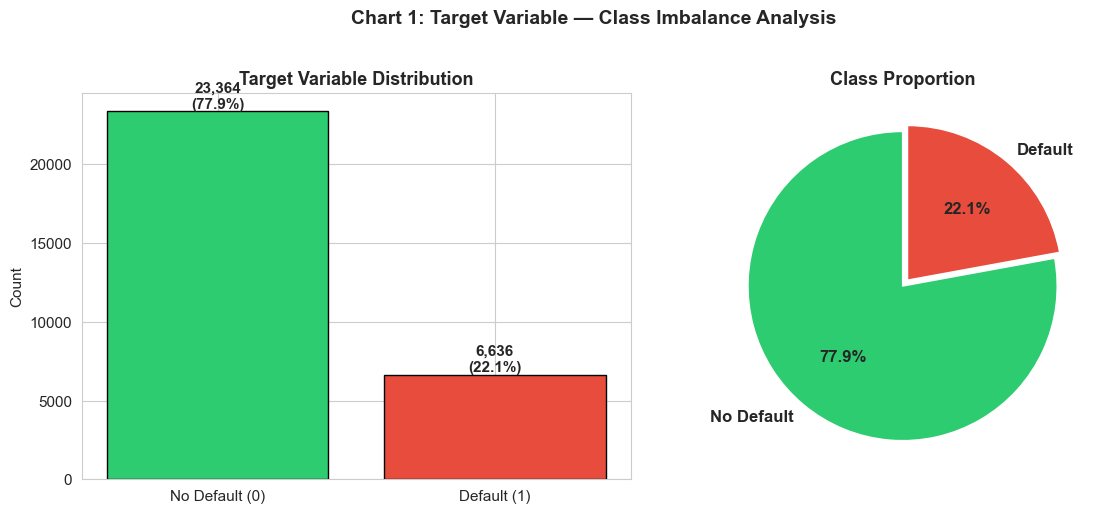

Class imbalance detected: ~78% No Default vs ~22% Default
This imbalance will be addressed using SMOTE in Step 6.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['DEFAULT'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['No Default (0)', 'Default (1)'], counts.values, color=colors, edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Target Variable Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=['No Default', 'Default'], colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Class Proportion', fontweight='bold')

fig.suptitle('Chart 1: Target Variable — Class Imbalance Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Class imbalance detected: ~78% No Default vs ~22% Default")
print("This imbalance will be addressed using SMOTE in Step 6.")

### Chart 2: Demographic Features Distribution

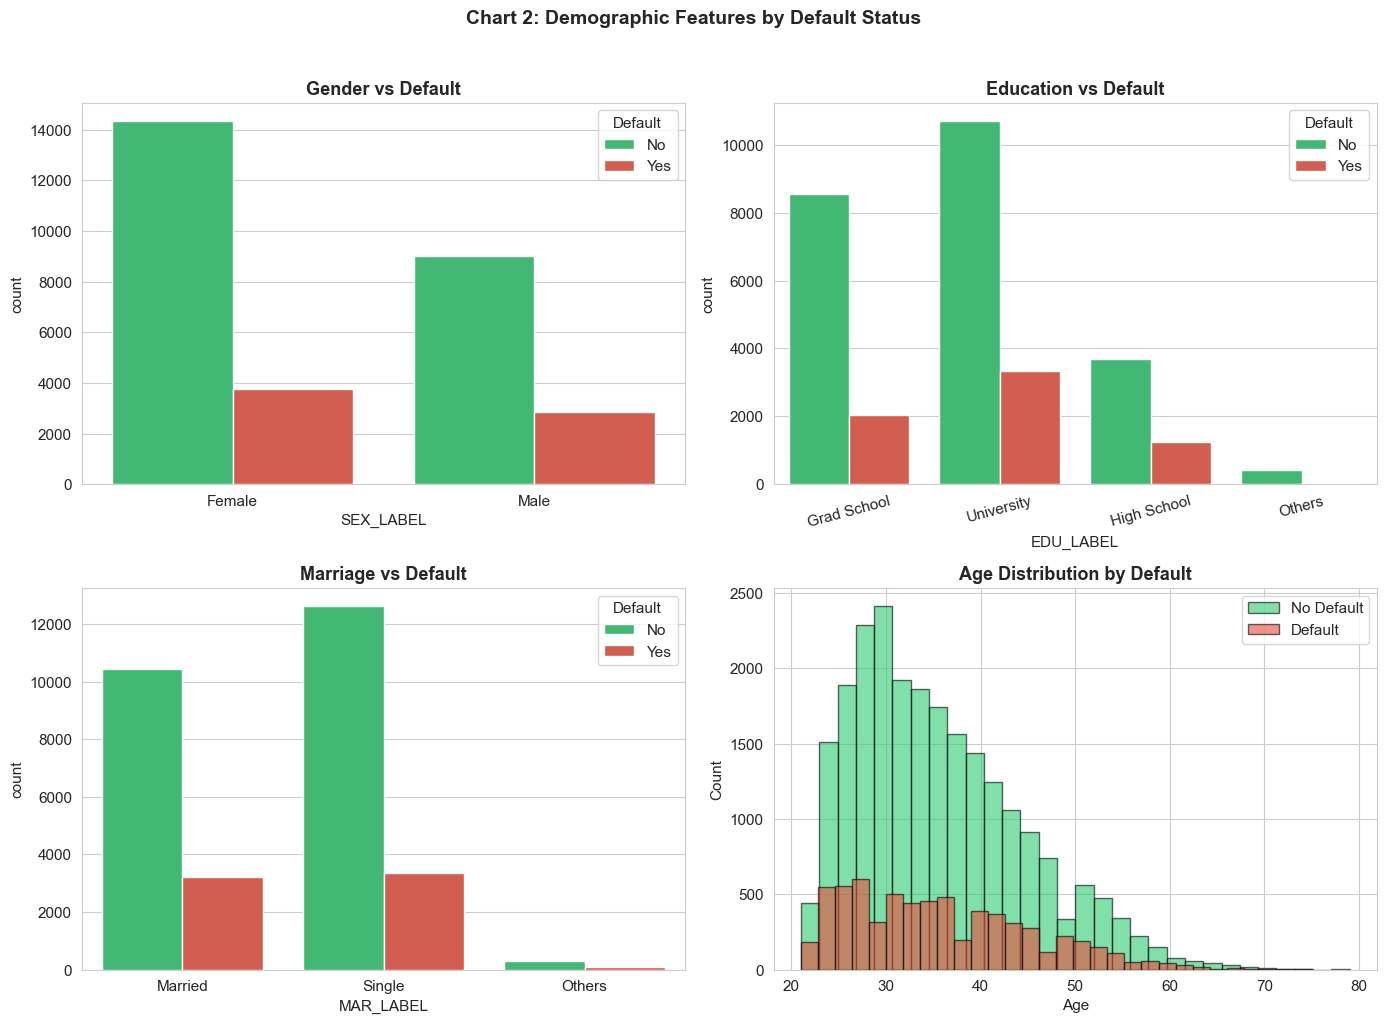

Default rates by demographic:

  SEX:
    Male: 24.2%
    Female: 20.8%

  EDUCATION:
    Grad School: 19.2%
    University: 23.7%
    High School: 25.2%
    Others: 7.1%

  MARRIAGE:
    Married: 23.5%
    Single: 20.9%
    Others: 23.6%


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SEX distribution by default
sex_labels = {1: 'Male', 2: 'Female'}
sex_data = df.copy()
sex_data['SEX_LABEL'] = sex_data['SEX'].map(sex_labels)
sns.countplot(data=sex_data, x='SEX_LABEL', hue='DEFAULT', ax=axes[0, 0],
              palette=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Gender vs Default', fontweight='bold')
axes[0, 0].legend(title='Default', labels=['No', 'Yes'])

# EDUCATION distribution by default
edu_labels = {1: 'Grad School', 2: 'University', 3: 'High School', 4: 'Others'}
edu_data = df.copy()
edu_data['EDU_LABEL'] = edu_data['EDUCATION'].map(edu_labels)
order = ['Grad School', 'University', 'High School', 'Others']
sns.countplot(data=edu_data, x='EDU_LABEL', hue='DEFAULT', ax=axes[0, 1],
              palette=['#2ecc71', '#e74c3c'], order=order)
axes[0, 1].set_title('Education vs Default', fontweight='bold')
axes[0, 1].legend(title='Default', labels=['No', 'Yes'])
axes[0, 1].tick_params(axis='x', rotation=15)

# MARRIAGE distribution by default
mar_labels = {1: 'Married', 2: 'Single', 3: 'Others'}
mar_data = df.copy()
mar_data['MAR_LABEL'] = mar_data['MARRIAGE'].map(mar_labels)
sns.countplot(data=mar_data, x='MAR_LABEL', hue='DEFAULT', ax=axes[1, 0],
              palette=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Marriage vs Default', fontweight='bold')
axes[1, 0].legend(title='Default', labels=['No', 'Yes'])

# AGE distribution by default
axes[1, 1].hist(df[df['DEFAULT'] == 0]['AGE'], bins=30, alpha=0.6,
                label='No Default', color='#2ecc71', edgecolor='black')
axes[1, 1].hist(df[df['DEFAULT'] == 1]['AGE'], bins=30, alpha=0.6,
                label='Default', color='#e74c3c', edgecolor='black')
axes[1, 1].set_title('Age Distribution by Default', fontweight='bold')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

fig.suptitle('Chart 2: Demographic Features by Default Status',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Default rates by demographic
print("Default rates by demographic:")
for col, labels in [('SEX', sex_labels), ('EDUCATION', edu_labels), ('MARRIAGE', mar_labels)]:
    print(f"\n  {col}:")
    for val, label in labels.items():
        rate = df[df[col] == val]['DEFAULT'].mean() * 100
        print(f"    {label}: {rate:.1f}%")

### Chart 3: Credit Limit Distribution

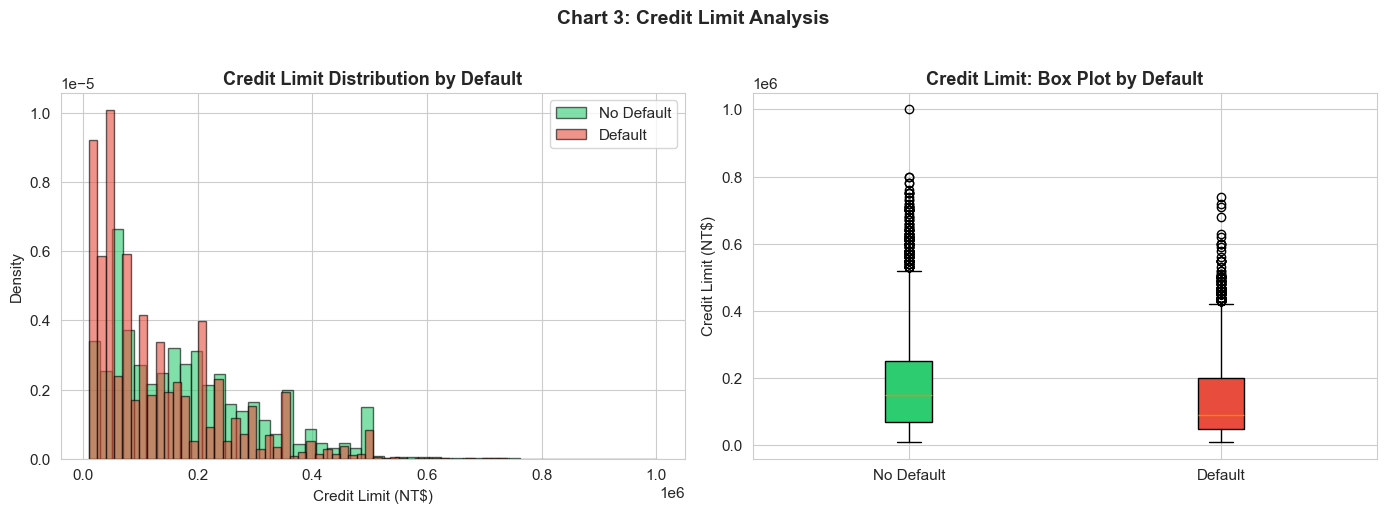

Credit Limit stats:
  No Default — Mean: 178,100, Median: 150,000
  Default    — Mean: 130,110, Median: 90,000


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[df['DEFAULT'] == 0]['LIMIT_BAL'], bins=50, alpha=0.6,
             label='No Default', color='#2ecc71', edgecolor='black', density=True)
axes[0].hist(df[df['DEFAULT'] == 1]['LIMIT_BAL'], bins=50, alpha=0.6,
             label='Default', color='#e74c3c', edgecolor='black', density=True)
axes[0].set_title('Credit Limit Distribution by Default', fontweight='bold')
axes[0].set_xlabel('Credit Limit (NT$)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Box plot
box_data = [df[df['DEFAULT'] == 0]['LIMIT_BAL'], df[df['DEFAULT'] == 1]['LIMIT_BAL']]
bp = axes[1].boxplot(box_data, labels=['No Default', 'Default'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title('Credit Limit: Box Plot by Default', fontweight='bold')
axes[1].set_ylabel('Credit Limit (NT$)')

fig.suptitle('Chart 3: Credit Limit Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Credit Limit stats:")
print(f"  No Default — Mean: {df[df['DEFAULT']==0]['LIMIT_BAL'].mean():,.0f}, "
      f"Median: {df[df['DEFAULT']==0]['LIMIT_BAL'].median():,.0f}")
print(f"  Default    — Mean: {df[df['DEFAULT']==1]['LIMIT_BAL'].mean():,.0f}, "
      f"Median: {df[df['DEFAULT']==1]['LIMIT_BAL'].median():,.0f}")

### Chart 4: Payment Status Heatmap

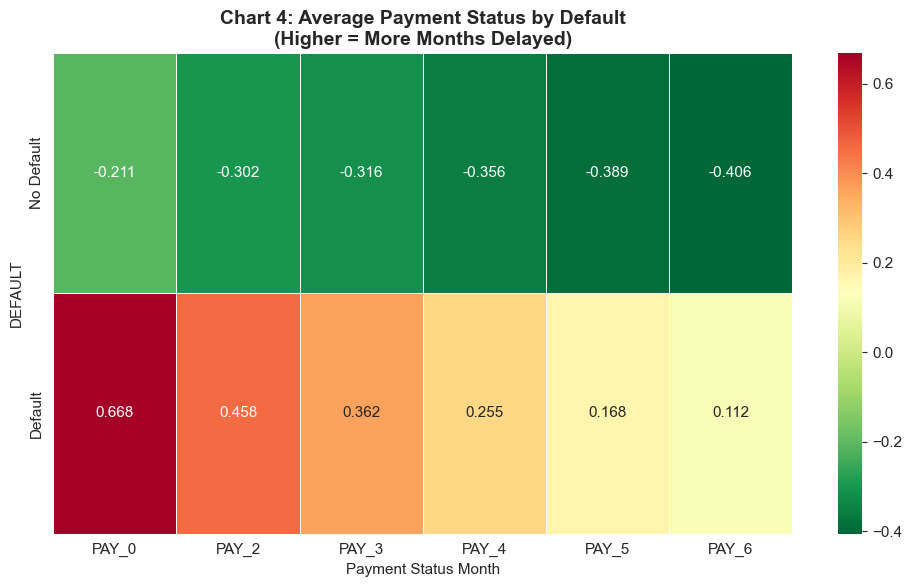

Payment delay is clearly higher for defaulters across all months.


In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

pay_status_default = df.groupby('DEFAULT')[pay_cols].mean()
sns.heatmap(pay_status_default, annot=True, fmt='.3f', cmap='RdYlGn_r',
            ax=ax, yticklabels=['No Default', 'Default'],
            linewidths=0.5, linecolor='white')
ax.set_title('Chart 4: Average Payment Status by Default\n'
             '(Higher = More Months Delayed)', fontsize=14, fontweight='bold')
ax.set_xlabel('Payment Status Month')
plt.tight_layout()
plt.show()

print("Payment delay is clearly higher for defaulters across all months.")

### Chart 5: Correlation Heatmap

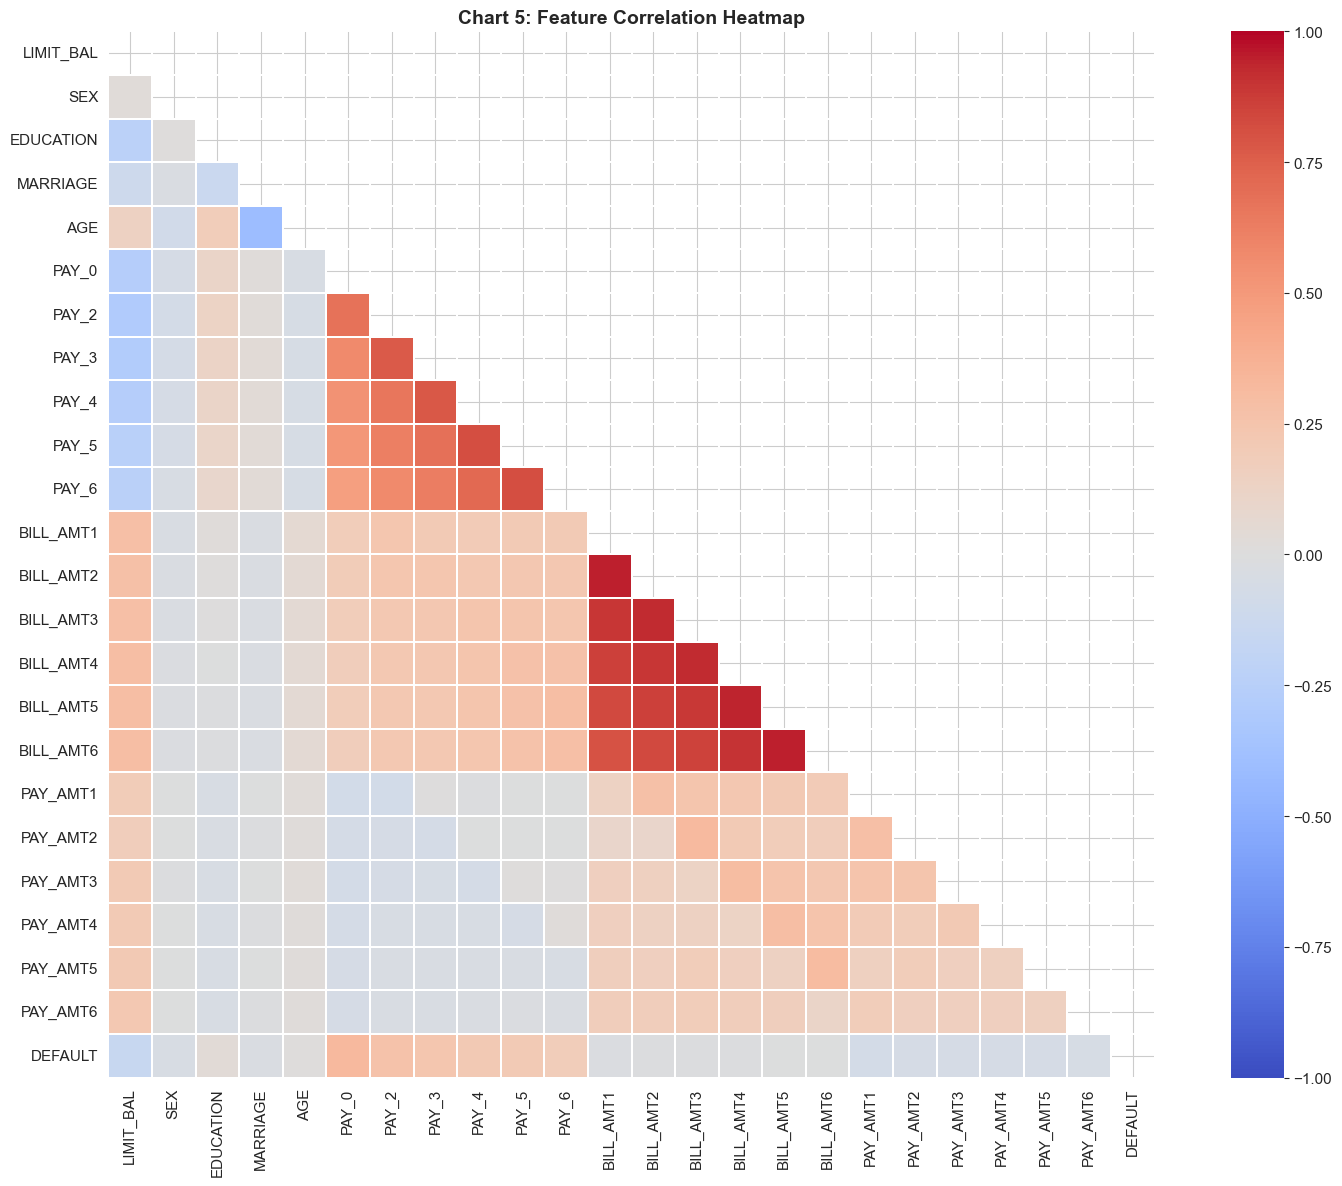

Top features correlated with DEFAULT:
  PAY_0                +0.3248
  PAY_2                +0.2636
  PAY_3                +0.2353
  PAY_4                +0.2166
  PAY_5                +0.2041
  PAY_6                +0.1869
  LIMIT_BAL            -0.1535
  PAY_AMT1             -0.0729
  PAY_AMT2             -0.0586
  PAY_AMT4             -0.0568


In [16]:
fig, ax = plt.subplots(figsize=(16, 12))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, ax=ax,
            annot=False, linewidths=0.3, linecolor='white',
            square=True, vmin=-1, vmax=1)
ax.set_title('Chart 5: Feature Correlation Heatmap',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
print("Top features correlated with DEFAULT:")
target_corr = corr['DEFAULT'].drop('DEFAULT').abs().sort_values(ascending=False)
for feat, val in target_corr.head(10).items():
    direction = "+" if corr.loc[feat, 'DEFAULT'] > 0 else "-"
    print(f"  {feat:<20} {direction}{val:.4f}")

### Chart 6: Bill Amount & Payment Trends

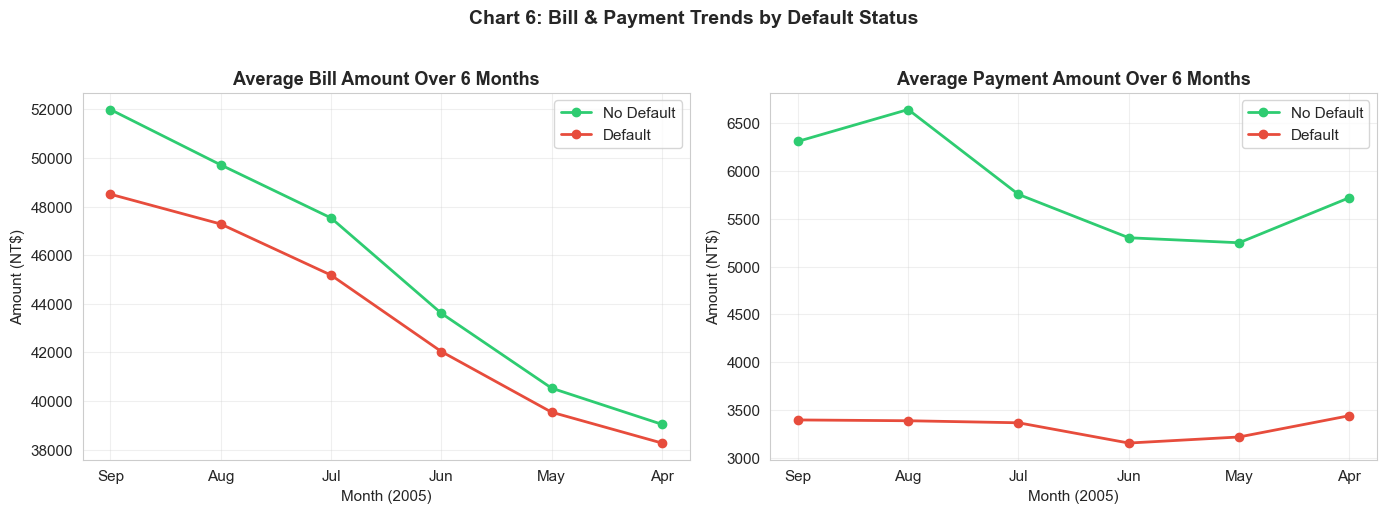

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
pay_amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
months = ['Sep', 'Aug', 'Jul', 'Jun', 'May', 'Apr']

# Bill amounts over time
for default_val, color, label in [(0, '#2ecc71', 'No Default'), (1, '#e74c3c', 'Default')]:
    subset = df[df['DEFAULT'] == default_val]
    means = [subset[c].mean() for c in bill_cols]
    axes[0].plot(months, means, marker='o', color=color, label=label, linewidth=2)
axes[0].set_title('Average Bill Amount Over 6 Months', fontweight='bold')
axes[0].set_xlabel('Month (2005)')
axes[0].set_ylabel('Amount (NT$)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Payment amounts over time
for default_val, color, label in [(0, '#2ecc71', 'No Default'), (1, '#e74c3c', 'Default')]:
    subset = df[df['DEFAULT'] == default_val]
    means = [subset[c].mean() for c in pay_amt_cols]
    axes[1].plot(months, means, marker='o', color=color, label=label, linewidth=2)
axes[1].set_title('Average Payment Amount Over 6 Months', fontweight='bold')
axes[1].set_xlabel('Month (2005)')
axes[1].set_ylabel('Amount (NT$)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Chart 6: Bill & Payment Trends by Default Status',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 4: Feature Engineering

In [18]:
# Credit Utilization Ratios (bill / credit limit)
for i in range(1, 7):
    df[f'UTIL_RATIO_{i}'] = df[f'BILL_AMT{i}'] / (df['LIMIT_BAL'] + 1)

util_cols = [f'UTIL_RATIO_{i}' for i in range(1, 7)]
df['AVG_UTILIZATION'] = df[util_cols].mean(axis=1)
df['MAX_UTILIZATION'] = df[util_cols].max(axis=1)
print("Created: UTIL_RATIO_1-6, AVG_UTILIZATION, MAX_UTILIZATION")

# Payment Ratios (payment / bill)
for i in range(1, 6):
    df[f'PAY_RATIO_{i}'] = df[f'PAY_AMT{i}'] / (df[f'BILL_AMT{i}'].abs() + 1)

pay_ratio_cols = [f'PAY_RATIO_{i}' for i in range(1, 6)]
df['AVG_PAY_RATIO'] = df[pay_ratio_cols].mean(axis=1)
print("Created: PAY_RATIO_1-5, AVG_PAY_RATIO")

# Payment Delay Summary Features
df['MAX_DELAY'] = df[pay_cols].max(axis=1)
df['AVG_DELAY'] = df[pay_cols].mean(axis=1)
df['NUM_DELAYS'] = (df[pay_cols] > 0).sum(axis=1)
df['RECENT_DELAY'] = df['PAY_0']
df['DELAY_TREND'] = df['PAY_0'] - df['PAY_6']
print("Created: MAX_DELAY, AVG_DELAY, NUM_DELAYS, RECENT_DELAY, DELAY_TREND")

# Bill & Payment Totals
df['TOTAL_BILL'] = df[bill_cols].sum(axis=1)
df['TOTAL_PAYMENT'] = df[pay_amt_cols].sum(axis=1)
df['OVERALL_PAY_RATIO'] = df['TOTAL_PAYMENT'] / (df['TOTAL_BILL'].abs() + 1)
df['BILL_TREND'] = (df['BILL_AMT1'] - df['BILL_AMT6']) / (df['BILL_AMT6'].abs() + 1)
print("Created: TOTAL_BILL, TOTAL_PAYMENT, OVERALL_PAY_RATIO, BILL_TREND")

# Age-based feature
df['LIMIT_PER_AGE'] = df['LIMIT_BAL'] / df['AGE']
print("Created: LIMIT_PER_AGE")

# Define final feature list
feature_cols = (
    ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE']
    + pay_cols
    + bill_cols
    + pay_amt_cols
    + ['AVG_UTILIZATION', 'MAX_UTILIZATION', 'AVG_PAY_RATIO',
       'MAX_DELAY', 'AVG_DELAY', 'NUM_DELAYS', 'RECENT_DELAY',
       'DELAY_TREND', 'BILL_TREND', 'TOTAL_BILL', 'TOTAL_PAYMENT',
       'OVERALL_PAY_RATIO', 'LIMIT_PER_AGE']
)

print(f"\nTotal features for modeling: {len(feature_cols)}")
print(f"Feature list: {feature_cols}")

Created: UTIL_RATIO_1-6, AVG_UTILIZATION, MAX_UTILIZATION
Created: PAY_RATIO_1-5, AVG_PAY_RATIO
Created: MAX_DELAY, AVG_DELAY, NUM_DELAYS, RECENT_DELAY, DELAY_TREND
Created: TOTAL_BILL, TOTAL_PAYMENT, OVERALL_PAY_RATIO, BILL_TREND
Created: LIMIT_PER_AGE

Total features for modeling: 36
Feature list: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_UTILIZATION', 'MAX_UTILIZATION', 'AVG_PAY_RATIO', 'MAX_DELAY', 'AVG_DELAY', 'NUM_DELAYS', 'RECENT_DELAY', 'DELAY_TREND', 'BILL_TREND', 'TOTAL_BILL', 'TOTAL_PAYMENT', 'OVERALL_PAY_RATIO', 'LIMIT_PER_AGE']


### Chart 7: Engineered Feature Distributions

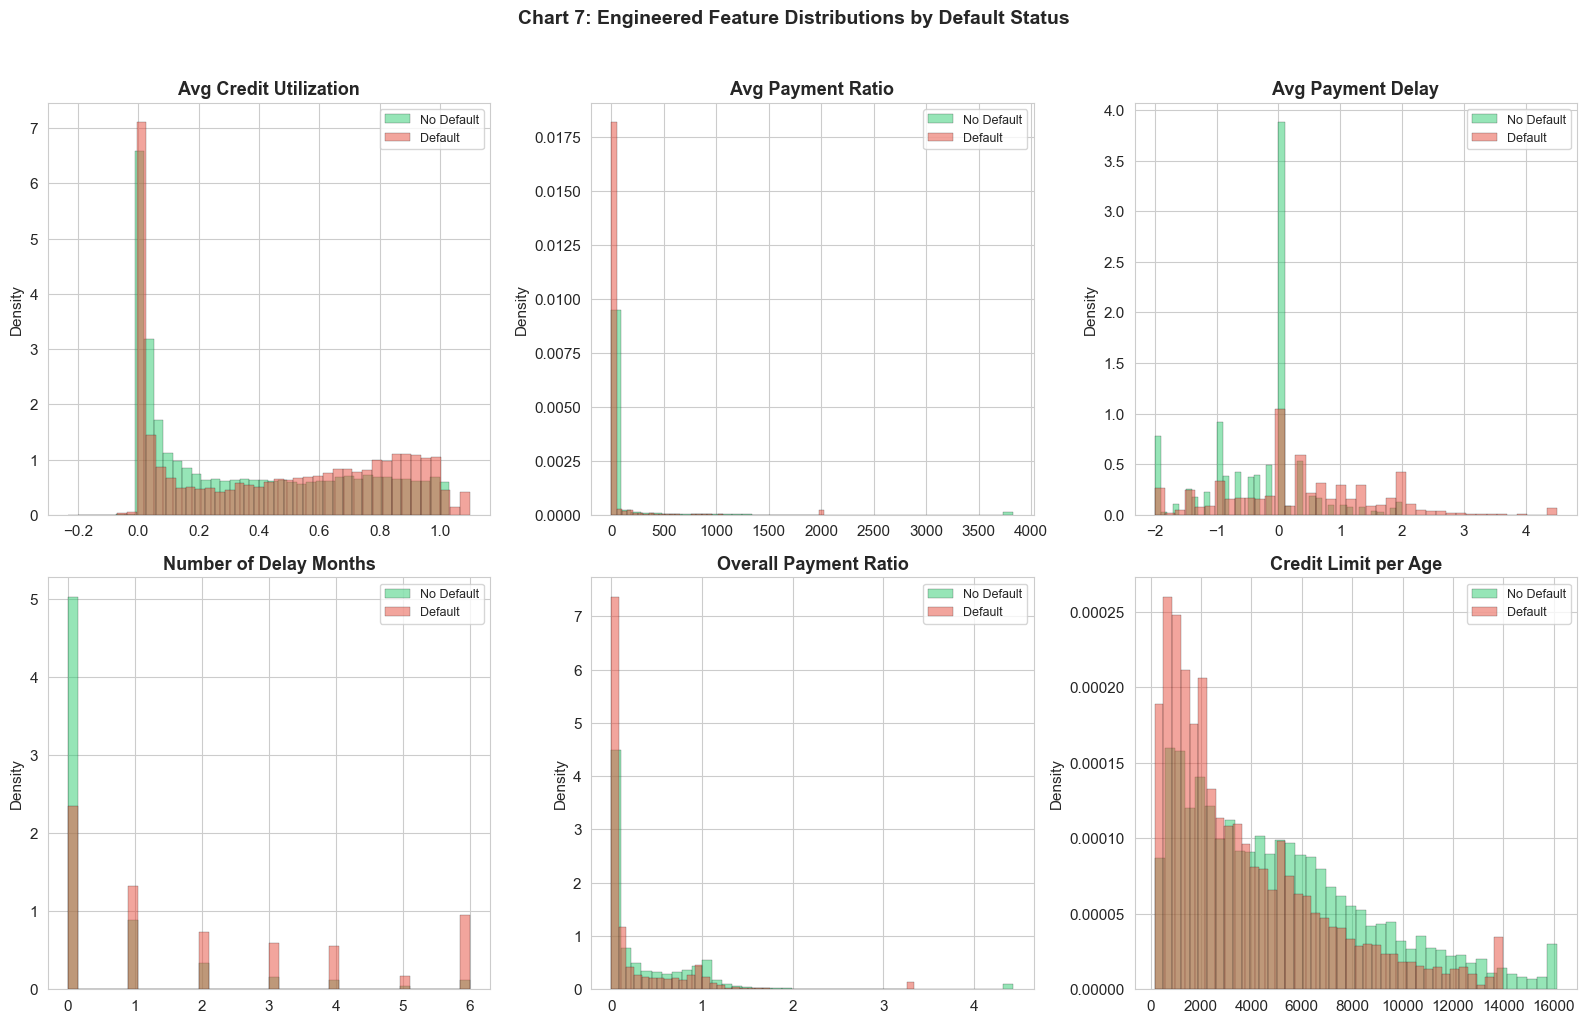

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
eng_features = ['AVG_UTILIZATION', 'AVG_PAY_RATIO', 'AVG_DELAY',
                'NUM_DELAYS', 'OVERALL_PAY_RATIO', 'LIMIT_PER_AGE']
eng_titles = ['Avg Credit Utilization', 'Avg Payment Ratio', 'Avg Payment Delay',
              'Number of Delay Months', 'Overall Payment Ratio', 'Credit Limit per Age']

for ax, feat, title in zip(axes.flat, eng_features, eng_titles):
    for default_val, color, label in [(0, '#2ecc71', 'No Default'), (1, '#e74c3c', 'Default')]:
        subset = df[df['DEFAULT'] == default_val][feat]
        q99 = subset.quantile(0.99)
        clipped = subset.clip(upper=q99)
        ax.hist(clipped, bins=40, alpha=0.5, color=color, label=label,
                density=True, edgecolor='black', linewidth=0.3)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylabel('Density')

fig.suptitle('Chart 7: Engineered Feature Distributions by Default Status',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 5: Feature Scaling & Train/Test Split (80/20)

In [20]:
X = df[feature_cols].values
y = df['DEFAULT'].values

# Handle any NaN/Inf from feature engineering
X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# StandardScaler: zero mean, unit variance (important for neural networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\nApplied StandardScaler:")
print(f"  Mean range after scaling: [{X_scaled.mean(axis=0).min():.6f}, {X_scaled.mean(axis=0).max():.6f}]")
print(f"  Std range after scaling:  [{X_scaled.std(axis=0).min():.4f}, {X_scaled.std(axis=0).max():.4f}]")

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTrain/Test Split (80/20 stratified):")
print(f"  Training set:  {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Test set:      {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"  Training default rate: {y_train.mean()*100:.2f}%")
print(f"  Test default rate:     {y_test.mean()*100:.2f}%")

Feature matrix shape: (30000, 36)
Target vector shape: (30000,)

Applied StandardScaler:
  Mean range after scaling: [-0.000000, 0.000000]
  Std range after scaling:  [1.0000, 1.0000]

Train/Test Split (80/20 stratified):
  Training set:  24,000 samples (80%)
  Test set:      6,000 samples (20%)
  Training default rate: 22.12%
  Test default rate:     22.12%


<cell_type>markdown</cell_type>---
## Step 6: Handling Class Imbalance with KMeansSMOTE

In [21]:
print("Before SMOTE:")
print(f"  Training samples: {len(y_train):,}")
print(f"  No Default: {np.sum(y_train == 0):,} ({np.mean(y_train == 0)*100:.1f}%)")
print(f"  Default:    {np.sum(y_train == 1):,} ({np.mean(y_train == 1)*100:.1f}%)")

smote = KMeansSMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Training samples: {len(y_train_smote):,}")
print(f"  No Default: {np.sum(y_train_smote == 0):,} ({np.mean(y_train_smote == 0)*100:.1f}%)")
print(f"  Default:    {np.sum(y_train_smote == 1):,} ({np.mean(y_train_smote == 1)*100:.1f}%)")
print(f"  Synthetic samples added: {len(y_train_smote) - len(y_train):,}")

Before SMOTE:
  Training samples: 24,000
  No Default: 18,691 (77.9%)
  Default:    5,309 (22.1%)

After SMOTE:
  Training samples: 37,383
  No Default: 18,691 (50.0%)
  Default:    18,692 (50.0%)
  Synthetic samples added: 13,383


In [22]:
# balance classes by under-sampling the majority class

default_count = df[df['DEFAULT'] == 1].shape[0]
non_default_indices = df[df['DEFAULT'] == 0].index
random_non_default_indices = np.random.choice(non_default_indices, default_count, replace=False)
default_indices = df[df['DEFAULT'] == 1].index
under_sample_indices = np.concatenate([default_indices, random_non_default_indices])
under_sample_df = df.loc[under_sample_indices]



#print distribution of target variable in the balanced dataset and classes
print("Target variable distribution in balanced dataset:")
print(under_sample_df['DEFAULT'].value_counts())

Target variable distribution in balanced dataset:
DEFAULT
1    6636
0    6636
Name: count, dtype: int64


<cell_type>markdown</cell_type>### Chart 8: SMOTE Before vs After — Scatter Plot Visualization

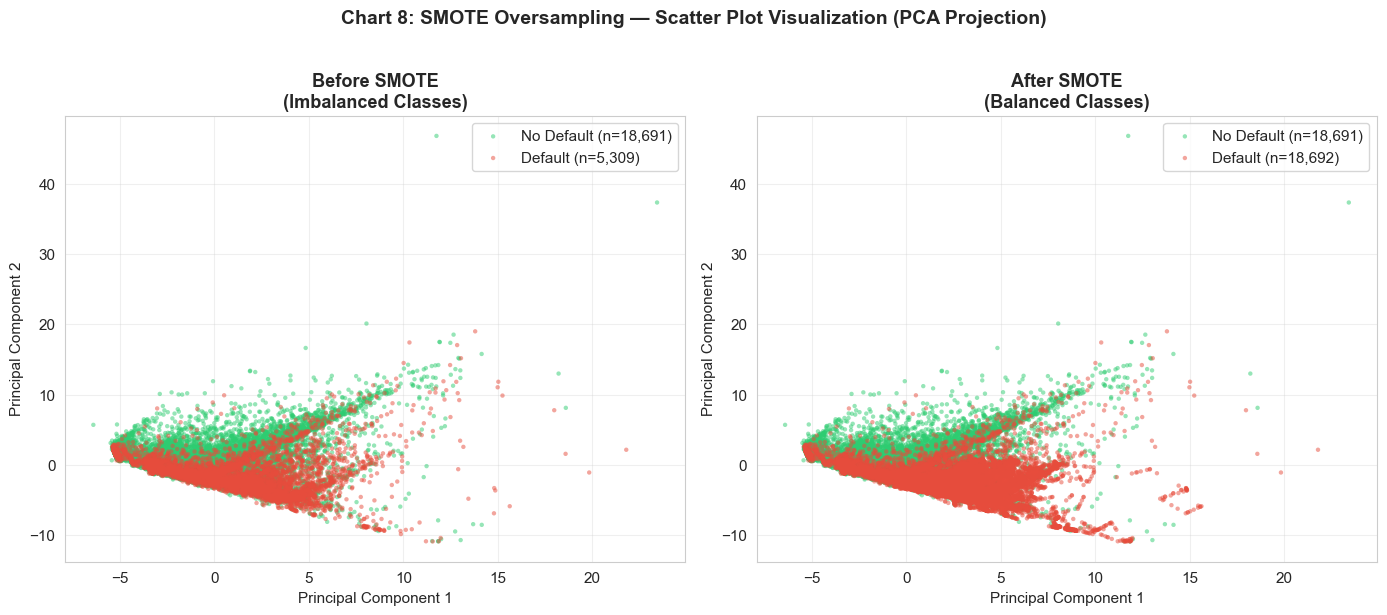

KMeansSMOTE applied. Classes are now balanced for training.
Note: KMeansSMOTE first clusters the data, then creates synthetic minority samples within cluster structure.
PCA variance explained: 45.2%


In [23]:
# Use PCA to reduce dimensions for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

# Fit PCA on original training data
X_train_pca = pca.fit_transform(X_train)
X_train_smote_pca = pca.transform(X_train_smote)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before SMOTE - scatter plot
for label, color, name in [(0, '#2ecc71', 'No Default'), (1, '#e74c3c', 'Default')]:
    mask = y_train == label
    axes[0].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], 
                    c=color, label=f'{name} (n={mask.sum():,})', 
                    alpha=0.5, s=10, edgecolors='none')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].set_title('Before SMOTE\n(Imbalanced Classes)', fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# After SMOTE - scatter plot
for label, color, name in [(0, '#2ecc71', 'No Default'), (1, '#e74c3c', 'Default')]:
    mask = y_train_smote == label
    axes[1].scatter(X_train_smote_pca[mask, 0], X_train_smote_pca[mask, 1], 
                    c=color, label=f'{name} (n={mask.sum():,})', 
                    alpha=0.5, s=10, edgecolors='none')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].set_title('After SMOTE\n(Balanced Classes)', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

fig.suptitle('Chart 8: SMOTE Oversampling — Scatter Plot Visualization (PCA Projection)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("KMeansSMOTE applied. Classes are now balanced for training.")
print("Note: KMeansSMOTE first clusters the data, then creates synthetic minority samples within cluster structure.")
print(f"PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

### Chart 9: NN Prediction Accuracy — Before vs After SMOTE (PCA Scatter)

Train a quick neural network on **imbalanced** vs **SMOTE-balanced** data, then visualize how each model classifies the test set in PCA space. Points are colored by whether the prediction was **correct** or **incorrect**, highlighting SMOTE's impact on minority-class detection.

Training NN on imbalanced data (50 epochs)...
Training NN on SMOTE-balanced data (50 epochs)...


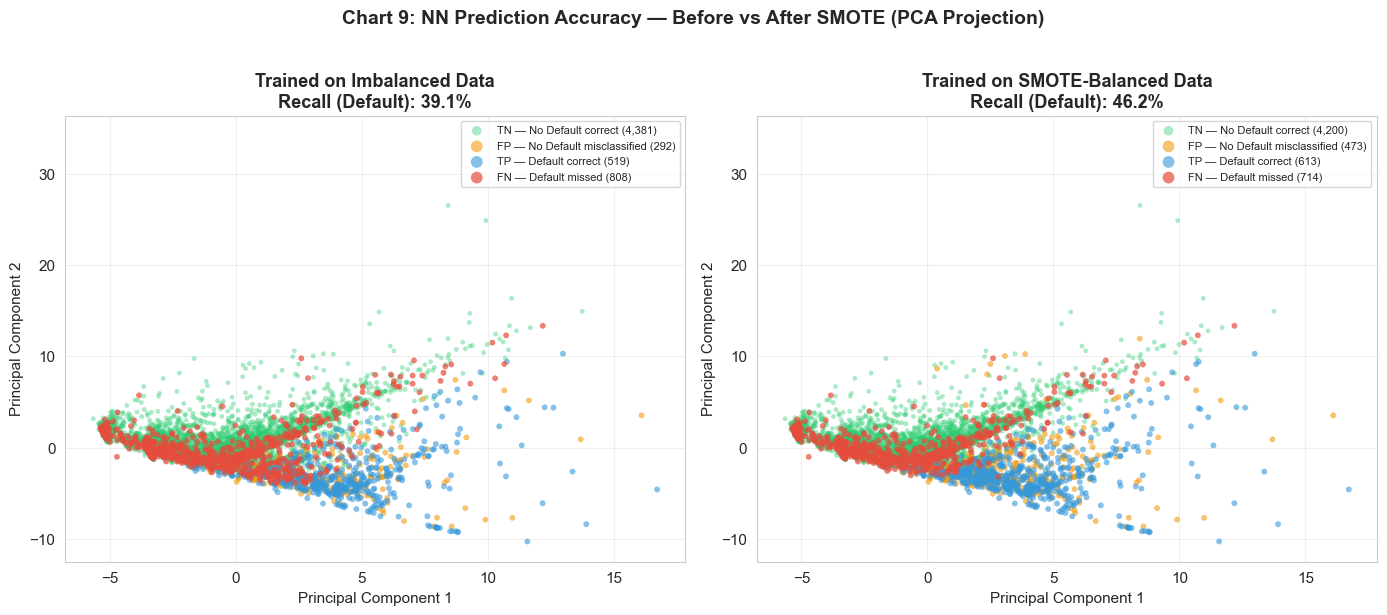

Imbalanced model — Defaults detected: 519/1327 (Recall: 39.1%)
SMOTE model     — Defaults detected: 613/1327 (Recall: 46.2%)

SMOTE training helps the model detect more defaulters (red dots decrease, blue dots increase).


In [24]:
# Train quick NNs: one on imbalanced data, one on SMOTE-balanced data
from sklearn.neural_network import MLPClassifier as _MLP

nn_imbalanced = _MLP(
    hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
    alpha=0.01, batch_size=32, learning_rate='constant',
    learning_rate_init=0.005, max_iter=50, tol=0,
    random_state=42, verbose=False
)
nn_smote_quick = _MLP(
    hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
    alpha=0.01, batch_size=32, learning_rate='constant',
    learning_rate_init=0.005, max_iter=50, tol=0,
    random_state=42, verbose=False
)

print("Training NN on imbalanced data (50 epochs)...")
nn_imbalanced.fit(X_train, y_train)
print("Training NN on SMOTE-balanced data (50 epochs)...")
nn_smote_quick.fit(X_train_smote, y_train_smote)

# Get predictions on test set
y_pred_imb = nn_imbalanced.predict(X_test)
y_pred_smt = nn_smote_quick.predict(X_test)

# Project test set into PCA space (reuse PCA from Chart 8)
X_test_pca = pca.transform(X_test)

# Classify each test point as correct/incorrect, split by true class
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred_cur, title in [
    (axes[0], y_pred_imb, 'Trained on Imbalanced Data'),
    (axes[1], y_pred_smt, 'Trained on SMOTE-Balanced Data'),
]:
    correct = y_pred_cur == y_test
    # True defaults correctly predicted
    mask_tp = (y_test == 1) & correct
    # True defaults missed (predicted as no-default)
    mask_fn = (y_test == 1) & ~correct
    # True no-defaults correctly predicted
    mask_tn = (y_test == 0) & correct
    # True no-defaults incorrectly predicted as default
    mask_fp = (y_test == 0) & ~correct

    ax.scatter(X_test_pca[mask_tn, 0], X_test_pca[mask_tn, 1],
               c='#2ecc71', s=12, alpha=0.4, label=f'TN — No Default correct ({mask_tn.sum():,})', edgecolors='none')
    ax.scatter(X_test_pca[mask_fp, 0], X_test_pca[mask_fp, 1],
               c='#f39c12', s=18, alpha=0.6, label=f'FP — No Default misclassified ({mask_fp.sum():,})', edgecolors='none')
    ax.scatter(X_test_pca[mask_tp, 0], X_test_pca[mask_tp, 1],
               c='#3498db', s=18, alpha=0.6, label=f'TP — Default correct ({mask_tp.sum():,})', edgecolors='none')
    ax.scatter(X_test_pca[mask_fn, 0], X_test_pca[mask_fn, 1],
               c='#e74c3c', s=18, alpha=0.7, label=f'FN — Default missed ({mask_fn.sum():,})', edgecolors='none')

    recall = mask_tp.sum() / (mask_tp.sum() + mask_fn.sum())
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_title(f'{title}\nRecall (Default): {recall:.1%}', fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, markerscale=2)
    ax.grid(True, alpha=0.3)

fig.suptitle('Chart 9: NN Prediction Accuracy — Before vs After SMOTE (PCA Projection)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Imbalanced model — Defaults detected: {(y_pred_imb[y_test == 1] == 1).sum()}/{(y_test == 1).sum()} "
      f"(Recall: {(y_pred_imb[y_test == 1] == 1).sum()/(y_test == 1).sum():.1%})")
print(f"SMOTE model     — Defaults detected: {(y_pred_smt[y_test == 1] == 1).sum()}/{(y_test == 1).sum()} "
      f"(Recall: {(y_pred_smt[y_test == 1] == 1).sum()/(y_test == 1).sum():.1%})")
print("\nSMOTE training helps the model detect more defaulters (red dots decrease, blue dots increase).")

<cell_type>markdown</cell_type>---
## Step 7: Neural Network Architecture Design & Training

In [25]:
# Define multiple NN architectures to compare
# Using fixed epochs (no early stopping) for consistent training
FIXED_EPOCHS = 100

nn_models = {
    'NN-Shallow (64-32)': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu', solver='adam', alpha=0.01,
        batch_size=32, learning_rate='constant', learning_rate_init=0.005,
        max_iter=FIXED_EPOCHS, early_stopping=False, tol=0,
        n_iter_no_change=FIXED_EPOCHS,
        random_state=42, verbose=False
    ),
    'NN-Medium (128-64-32)': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu', solver='adam', alpha=0.01,
        batch_size=32, learning_rate='constant', learning_rate_init=0.005,
        max_iter=FIXED_EPOCHS, early_stopping=False, tol=0,
        n_iter_no_change=FIXED_EPOCHS,
        random_state=42, verbose=False
    ),
    'NN-Deep (128-64-32-16)': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32, 16),
        activation='relu', solver='adam', alpha=0.01,
        batch_size=32, learning_rate='constant', learning_rate_init=0.005,
        max_iter=FIXED_EPOCHS, early_stopping=False, tol=0,
        n_iter_no_change=FIXED_EPOCHS,
        random_state=42, verbose=False
    ),
    'NN-Wide (256-128)': MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu', solver='adam', alpha=0.01,
        batch_size=64, learning_rate='constant', learning_rate_init=0.005,
        max_iter=FIXED_EPOCHS, early_stopping=False, tol=0,
        n_iter_no_change=FIXED_EPOCHS,
        random_state=42, verbose=False
    ),
}

print(f"Neural Network Architectures (all trained for {FIXED_EPOCHS} epochs):")
for name, model in nn_models.items():
    layers = model.hidden_layer_sizes
    total_params = 0
    input_size = X_train.shape[1]
    prev = input_size
    for l in layers:
        total_params += prev * l + l
        prev = l
    total_params += prev * 1 + 1
    print(f"\n  {name}:")
    print(f"    Layers: Input({input_size}) -> {' -> '.join(str(l) for l in layers)} -> Output(1)")
    print(f"    Activation: {model.activation}, Solver: {model.solver}")
    print(f"    Approx. parameters: {total_params:,}")
    print(f"    Regularization (alpha): {model.alpha}")
    print(f"    Batch size: {model.batch_size}, Learning rate: {model.learning_rate_init}")

Neural Network Architectures (all trained for 100 epochs):

  NN-Shallow (64-32):
    Layers: Input(36) -> 64 -> 32 -> Output(1)
    Activation: relu, Solver: adam
    Approx. parameters: 4,481
    Regularization (alpha): 0.01
    Batch size: 32, Learning rate: 0.005

  NN-Medium (128-64-32):
    Layers: Input(36) -> 128 -> 64 -> 32 -> Output(1)
    Activation: relu, Solver: adam
    Approx. parameters: 15,105
    Regularization (alpha): 0.01
    Batch size: 32, Learning rate: 0.005

  NN-Deep (128-64-32-16):
    Layers: Input(36) -> 128 -> 64 -> 32 -> 16 -> Output(1)
    Activation: relu, Solver: adam
    Approx. parameters: 15,617
    Regularization (alpha): 0.01
    Batch size: 32, Learning rate: 0.005

  NN-Wide (256-128):
    Layers: Input(36) -> 256 -> 128 -> Output(1)
    Activation: relu, Solver: adam
    Approx. parameters: 42,497
    Regularization (alpha): 0.01
    Batch size: 64, Learning rate: 0.005


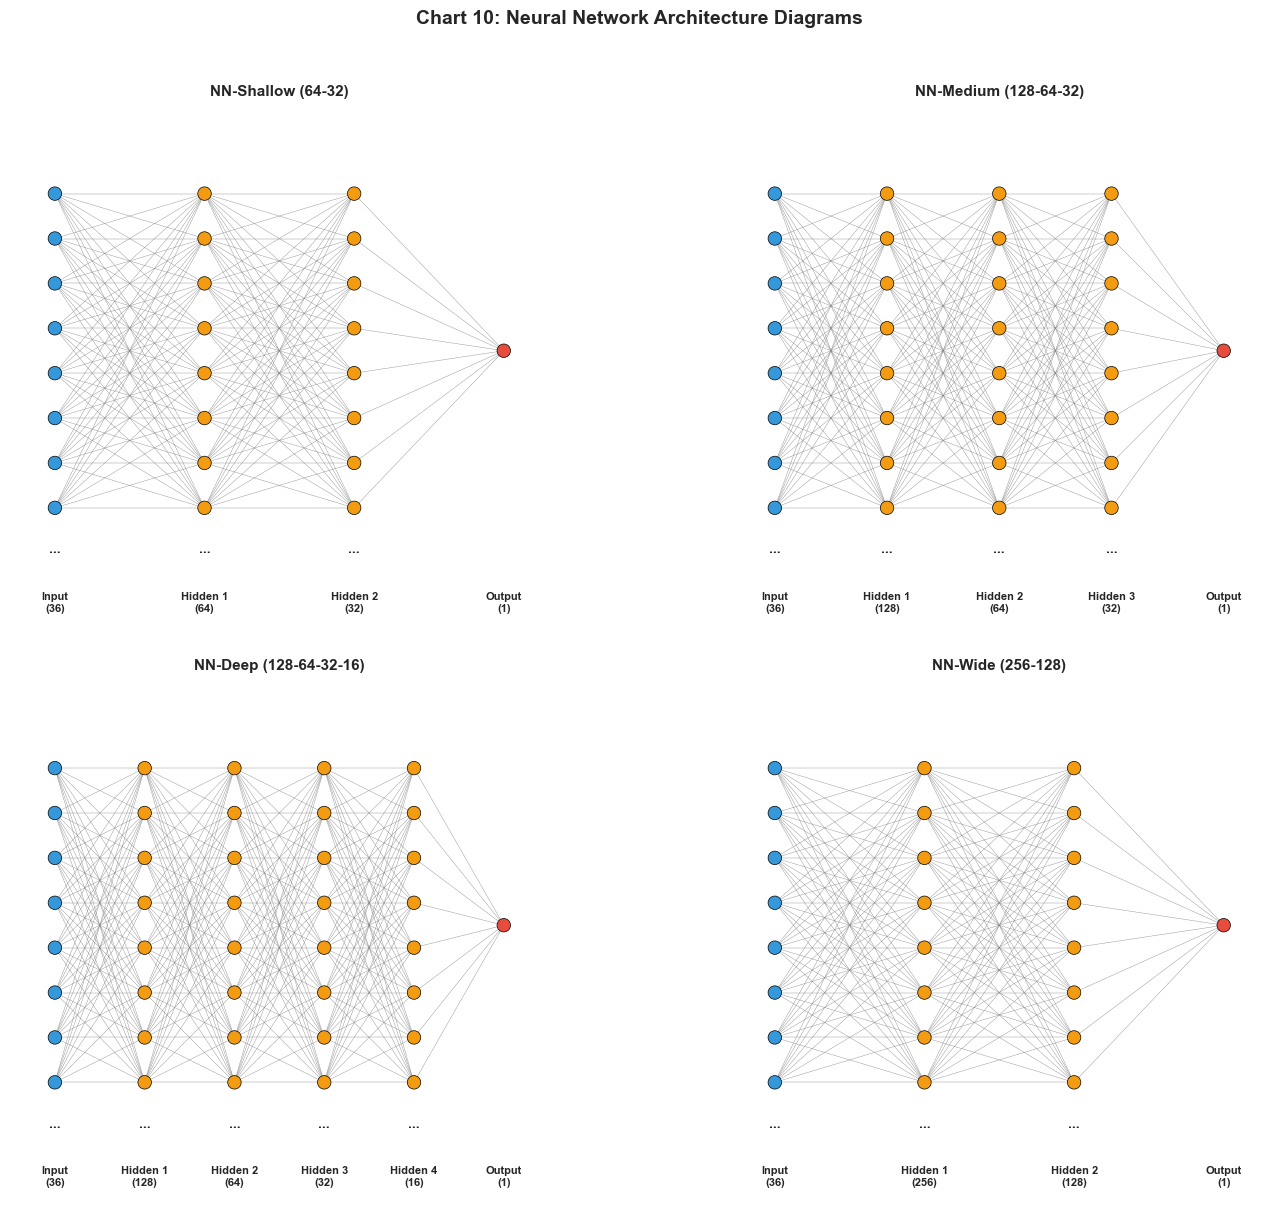

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, (name, model) in zip(axes.flat, nn_models.items()):
    layers = [X_train.shape[1]] + list(model.hidden_layer_sizes) + [1]
    layer_labels = ['Input'] + [f'Hidden {i+1}' for i in range(len(model.hidden_layer_sizes))] + ['Output']
    max_neurons = max(layers)

    for i, (n_neurons, label) in enumerate(zip(layers, layer_labels)):
        x = i / (len(layers) - 1)
        display_n = min(n_neurons, 8)
        spacing = 0.8 / max(display_n, 1)

        for j in range(display_n):
            y_pos = 0.5 + (j - display_n / 2 + 0.5) * spacing
            color = '#3498db' if i == 0 else ('#e74c3c' if i == len(layers) - 1 else '#f39c12')
            circle = plt.Circle((x, y_pos), 0.015, color=color, ec='black', linewidth=0.5, zorder=3)
            ax.add_patch(circle)

            if i < len(layers) - 1:
                next_n = min(layers[i + 1], 8)
                next_spacing = 0.8 / max(next_n, 1)
                for k in range(next_n):
                    next_y = 0.5 + (k - next_n / 2 + 0.5) * next_spacing
                    ax.plot([x, (i + 1) / (len(layers) - 1)], [y_pos, next_y],
                            'gray', alpha=0.9, linewidth=0.3, zorder=1)

        if n_neurons > 8:
            ax.text(x, 0.5 - display_n / 2 * spacing - 0.05, '...', ha='center',
                    fontsize=10, fontweight='bold')

        ax.text(x, -0.08, f'{label}\n({n_neurons})', ha='center', fontsize=8, fontweight='bold')

    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.15, 1.05)
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_aspect('equal')
    ax.axis('off')

fig.suptitle('Chart 10: Neural Network Architecture Diagrams',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Training All Neural Networks

In [27]:
print(f"Training neural networks (with SMOTE-balanced data, {FIXED_EPOCHS} epochs each)...\n")
results = {}

for name, model in nn_models.items():
    print(f"  Training {name}...")
    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    gmean = np.sqrt(sensitivity * specificity)

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc_roc': roc_auc_score(y_test, y_prob),
        'avg_precision': average_precision_score(y_test, y_prob),
        'gmean': gmean,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'epochs': model.n_iter_,
    }

    print(f"    Epochs: {model.n_iter_} | Accuracy: {results[name]['accuracy']:.4f} | "
          f"AUC-ROC: {results[name]['auc_roc']:.4f} | F1: {results[name]['f1']:.4f}\n")

print("All models trained successfully!")

Training neural networks (with SMOTE-balanced data, 100 epochs each)...

  Training NN-Shallow (64-32)...
    Epochs: 100 | Accuracy: 0.8037 | AUC-ROC: 0.7665 | F1: 0.4949

  Training NN-Medium (128-64-32)...
    Epochs: 100 | Accuracy: 0.8050 | AUC-ROC: 0.7653 | F1: 0.5034

  Training NN-Deep (128-64-32-16)...
    Epochs: 100 | Accuracy: 0.8077 | AUC-ROC: 0.7610 | F1: 0.5051

  Training NN-Wide (256-128)...
    Epochs: 100 | Accuracy: 0.8060 | AUC-ROC: 0.7667 | F1: 0.4930

All models trained successfully!


In [28]:
# Also train best architecture WITHOUT SMOTE for comparison
print(f"Training NN-Deep WITHOUT SMOTE for comparison ({FIXED_EPOCHS} epochs)...")
nn_no_smote = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32, 16),
    activation='relu', solver='adam', alpha=0.01,
    batch_size=32, learning_rate='constant', learning_rate_init=0.005,
    max_iter=FIXED_EPOCHS, early_stopping=False, tol=0,
    n_iter_no_change=FIXED_EPOCHS,
    random_state=42
)
nn_no_smote.fit(X_train, y_train)
y_pred_no_smote = nn_no_smote.predict(X_test)
y_prob_no_smote = nn_no_smote.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_no_smote).ravel()
results_no_smote = {
    'accuracy': accuracy_score(y_test, y_pred_no_smote),
    'precision': precision_score(y_test, y_pred_no_smote),
    'recall': recall_score(y_test, y_pred_no_smote),
    'f1': f1_score(y_test, y_pred_no_smote),
    'auc_roc': roc_auc_score(y_test, y_prob_no_smote),
    'gmean': np.sqrt((tp / (tp + fn)) * (tn / (tn + fp))),
    'y_pred': y_pred_no_smote,
    'y_prob': y_prob_no_smote,
}
print(f"Done. AUC-ROC (no SMOTE): {results_no_smote['auc_roc']:.4f}")

Training NN-Deep WITHOUT SMOTE for comparison (100 epochs)...
Done. AUC-ROC (no SMOTE): 0.7698


<cell_type>markdown</cell_type>### Chart 10: Training Loss Curves

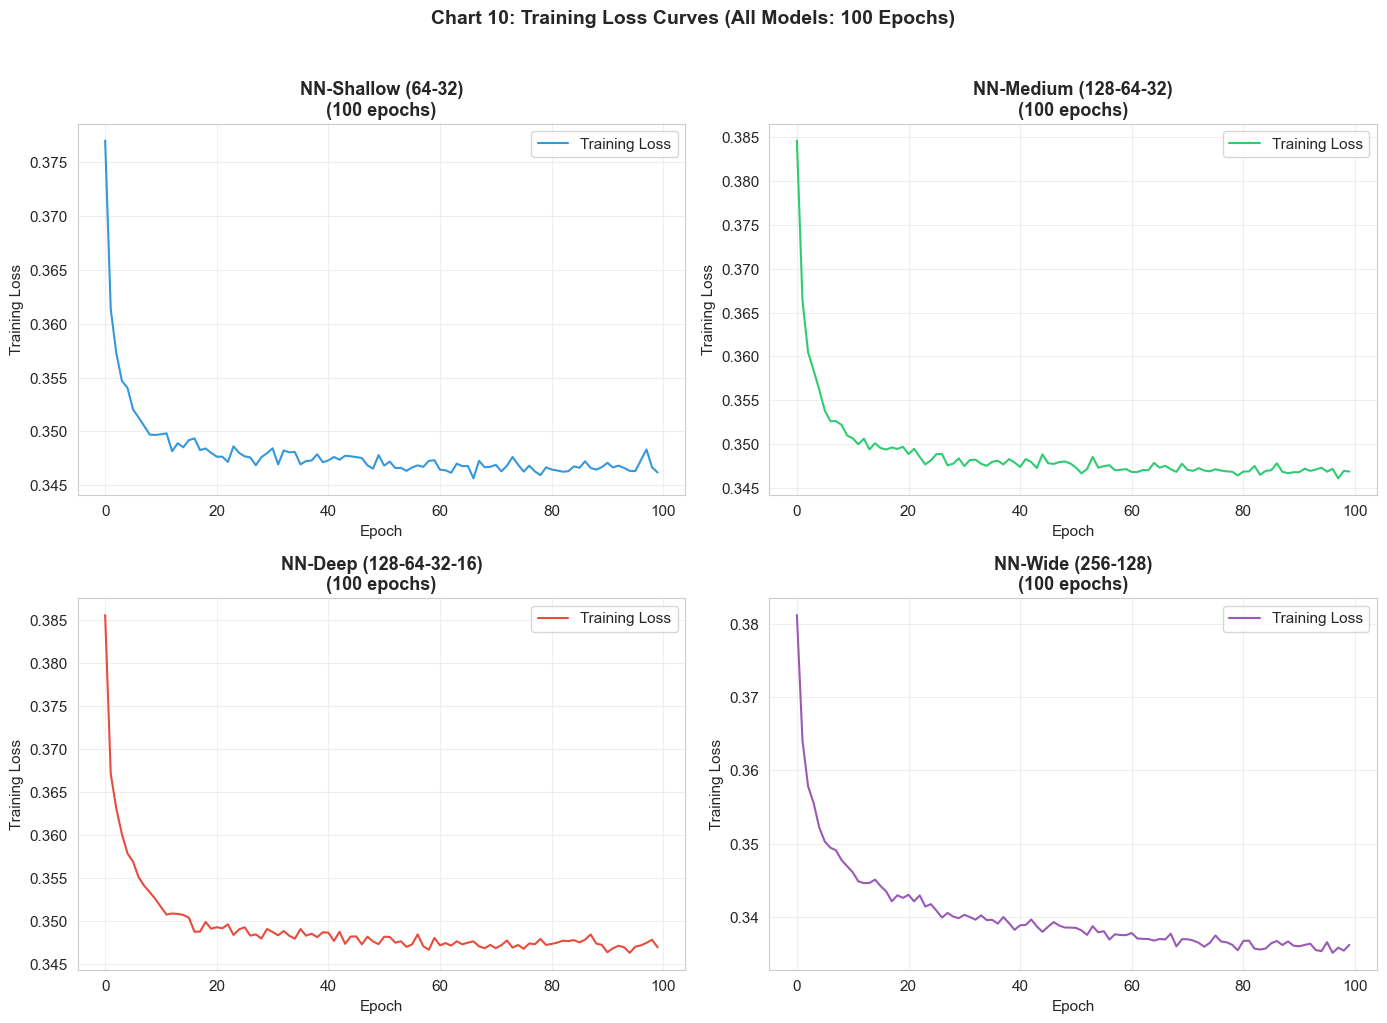

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for ax, ((name, res), color) in zip(axes.flat, zip(results.items(), colors)):
    model = res['model']
    ax.plot(model.loss_curve_, color=color, linewidth=1.5, label='Training Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss')
    ax.set_title(f'{name}\n({res["epochs"]} epochs)', fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Chart 10: Training Loss Curves (All Models: {FIXED_EPOCHS} Epochs)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 8: Model Evaluation & Interpretation

In [30]:
best_name = max(results, key=lambda k: results[k]['auc_roc'])
best = results[best_name]

print(f"Best Model: {best_name}")
print(f"\nClassification Report ({best_name}):")
print(classification_report(y_test, best['y_pred'],
                            target_names=['No Default', 'Default']))

Best Model: NN-Wide (256-128)

Classification Report (NN-Wide (256-128)):
              precision    recall  f1-score   support

  No Default       0.85      0.91      0.88      4673
     Default       0.58      0.43      0.49      1327

    accuracy                           0.81      6000
   macro avg       0.72      0.67      0.69      6000
weighted avg       0.79      0.81      0.79      6000



In [31]:
print("All Neural Network Results (with SMOTE):")
print("-" * 95)
header = f"{'Model':<25} {'Accuracy':>9} {'AUC-ROC':>9} {'F1':>9} {'Precision':>10} {'Recall':>9} {'G-Mean':>9} {'Epochs':>7}"
print(header)
print("-" * 95)
for name, res in sorted(results.items(), key=lambda x: x[1]['auc_roc'], reverse=True):
    print(f"{name:<25} {res['accuracy']:>9.4f} {res['auc_roc']:>9.4f} {res['f1']:>9.4f} "
          f"{res['precision']:>10.4f} {res['recall']:>9.4f} {res['gmean']:>9.4f} {res['epochs']:>7}")
print("-" * 95)

All Neural Network Results (with SMOTE):
-----------------------------------------------------------------------------------------------
Model                      Accuracy   AUC-ROC        F1  Precision    Recall    G-Mean  Epochs
-----------------------------------------------------------------------------------------------
NN-Wide (256-128)            0.8060    0.7667    0.4930     0.5841    0.4265    0.6243     100
NN-Shallow (64-32)           0.8037    0.7665    0.4949     0.5741    0.4348    0.6285     100
NN-Medium (128-64-32)        0.8050    0.7653    0.5034     0.5763    0.4469    0.6365     100
NN-Deep (128-64-32-16)       0.8077    0.7610    0.5051     0.5861    0.4439    0.6359     100
-----------------------------------------------------------------------------------------------


### Chart 12: ROC & Precision-Recall Curves

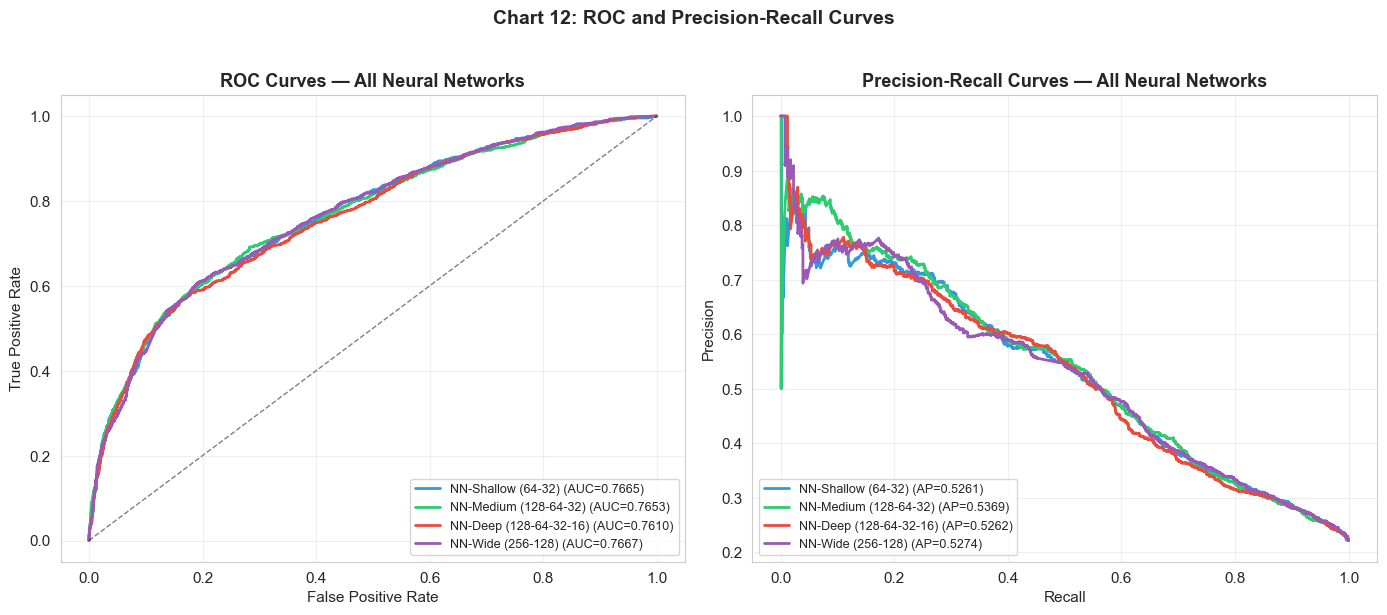

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

# ROC Curves
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc_roc']:.4f})",
                 color=color, linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Neural Networks', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curves
for (name, res), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    axes[1].plot(rec, prec, label=f"{name} (AP={res['avg_precision']:.4f})",
                 color=color, linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Neural Networks', fontweight='bold')
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Chart 12: ROC and Precision-Recall Curves',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Chart 13: Performance Metrics Bar Comparison

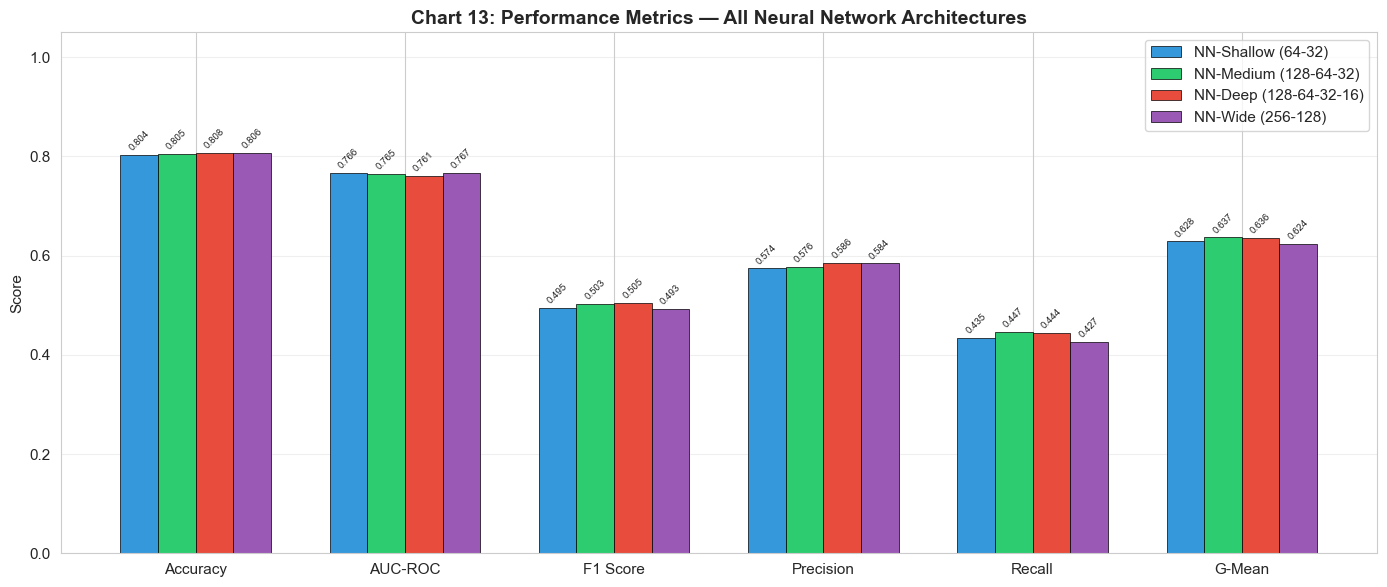

In [33]:
fig, ax = plt.subplots(figsize=(14, 6))

metrics_to_plot = ['accuracy', 'auc_roc', 'f1', 'precision', 'recall', 'gmean']
metric_labels = ['Accuracy', 'AUC-ROC', 'F1 Score', 'Precision', 'Recall', 'G-Mean']
x = np.arange(len(metrics_to_plot))
width = 0.18
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, ((name, res), color) in enumerate(zip(results.items(), colors)):
    values = [res[m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, values, width, label=name, color=color, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Chart 13: Performance Metrics — All Neural Network Architectures',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 1.05)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 14: Confusion Matrices

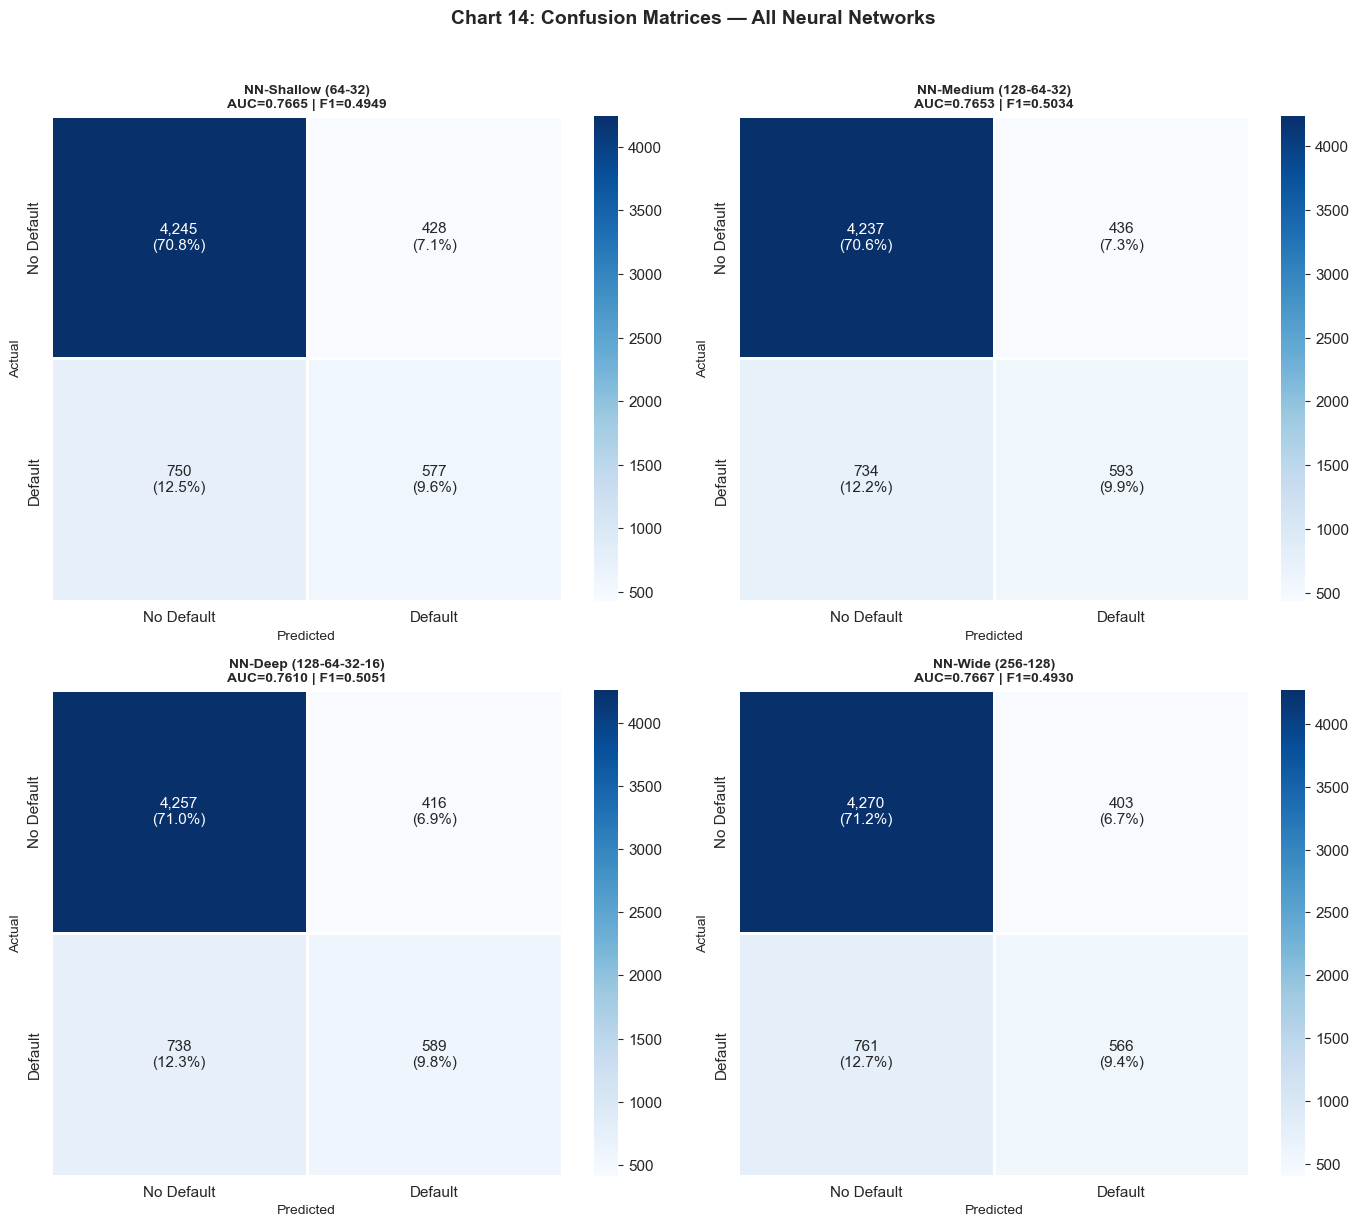

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (name, res) in zip(axes.flat, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    total = cm.sum()
    annot = np.array([[f'{v:,}\n({v/total*100:.1f}%)' for v in row] for row in cm])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'],
                linewidths=1, linecolor='white')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_title(f'{name}\nAUC={res["auc_roc"]:.4f} | F1={res["f1"]:.4f}',
                 fontweight='bold', fontsize=10)

fig.suptitle('Chart 14: Confusion Matrices — All Neural Networks',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Chart 15: SMOTE Impact Comparison

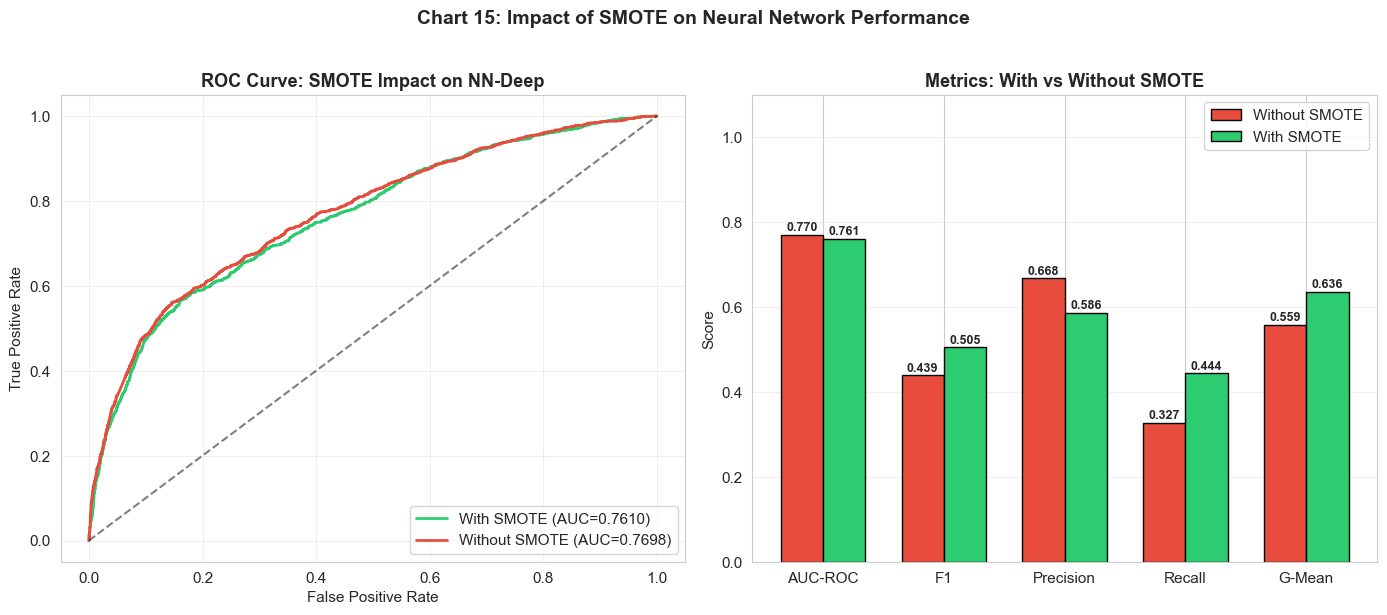

SMOTE Impact on NN-Deep (128-64-32-16):
-------------------------------------------------------
Metric            Without SMOTE      With SMOTE     Change
-------------------------------------------------------
AUC-ROC                  0.7698          0.7610     -0.88%
F1                       0.4390          0.5051     +6.61%
Precision                0.6677          0.5861     -8.16%
Recall                   0.3271          0.4439    +11.68%
G-Mean                   0.5585          0.6359     +7.74%


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC comparison: with vs without SMOTE
fpr_sm, tpr_sm, _ = roc_curve(y_test, results['NN-Deep (128-64-32-16)']['y_prob'])
fpr_no, tpr_no, _ = roc_curve(y_test, y_prob_no_smote)

axes[0].plot(fpr_sm, tpr_sm, color='#2ecc71', linewidth=2,
             label=f"With SMOTE (AUC={results['NN-Deep (128-64-32-16)']['auc_roc']:.4f})")
axes[0].plot(fpr_no, tpr_no, color='#e74c3c', linewidth=2,
             label=f"Without SMOTE (AUC={results_no_smote['auc_roc']:.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve: SMOTE Impact on NN-Deep', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Metrics comparison bar chart
metrics = ['auc_roc', 'f1', 'precision', 'recall', 'gmean']
metric_names = ['AUC-ROC', 'F1', 'Precision', 'Recall', 'G-Mean']
x = np.arange(len(metrics))
width = 0.35

deep_res = results['NN-Deep (128-64-32-16)']
vals_smote = [deep_res[m] for m in metrics]
vals_no = [results_no_smote[m] for m in metrics]

bars1 = axes[1].bar(x - width/2, vals_no, width, label='Without SMOTE',
                     color='#e74c3c', edgecolor='black')
bars2 = axes[1].bar(x + width/2, vals_smote, width, label='With SMOTE',
                     color='#2ecc71', edgecolor='black')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
                 ha='center', fontsize=9, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_names)
axes[1].set_ylabel('Score')
axes[1].set_title('Metrics: With vs Without SMOTE', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, axis='y', alpha=0.3)

fig.suptitle('Chart 15: Impact of SMOTE on Neural Network Performance',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# SMOTE impact summary table
print("SMOTE Impact on NN-Deep (128-64-32-16):")
print("-" * 55)
print(f"{'Metric':<15} {'Without SMOTE':>15} {'With SMOTE':>15} {'Change':>10}")
print("-" * 55)
for m, label in zip(metrics, metric_names):
    change = (deep_res[m] - results_no_smote[m]) * 100
    print(f"{label:<15} {results_no_smote[m]:>15.4f} {deep_res[m]:>15.4f} {change:>+9.2f}%")

### Chart 16: Feature Importance (Permutation-based)

Calculating feature importance (permutation-based)... this may take a moment.


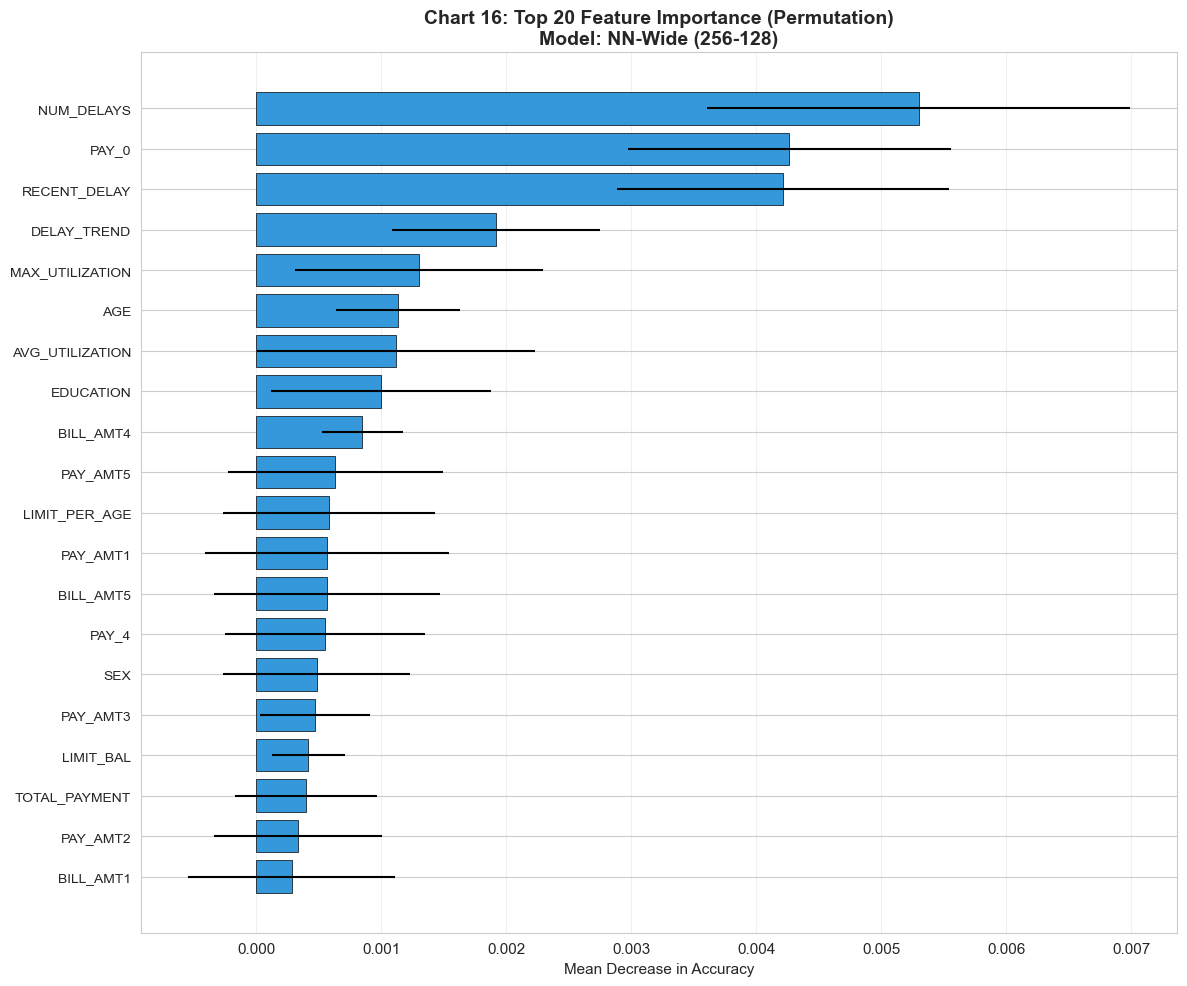


Top 10 most important features for NN-Wide (256-128):
  NUM_DELAYS                Importance: 0.0053 (+/- 0.0017)
  PAY_0                     Importance: 0.0043 (+/- 0.0013)
  RECENT_DELAY              Importance: 0.0042 (+/- 0.0013)
  DELAY_TREND               Importance: 0.0019 (+/- 0.0008)
  MAX_UTILIZATION           Importance: 0.0013 (+/- 0.0010)
  AGE                       Importance: 0.0011 (+/- 0.0005)
  AVG_UTILIZATION           Importance: 0.0011 (+/- 0.0011)
  EDUCATION                 Importance: 0.0010 (+/- 0.0009)
  BILL_AMT4                 Importance: 0.0009 (+/- 0.0003)
  PAY_AMT5                  Importance: 0.0006 (+/- 0.0009)


In [36]:
print("Calculating feature importance (permutation-based)... this may take a moment.")

best_model = results[best_name]['model']
perm_result = permutation_importance(best_model, X_test, y_test,
                                      n_repeats=10, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
top_n = 20
top_features = importance_df.head(top_n)

bars = ax.barh(range(top_n), top_features['Importance'].values[::-1],
               xerr=top_features['Std'].values[::-1],
               color='#3498db', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'].values[::-1], fontsize=10)
ax.set_xlabel('Mean Decrease in Accuracy')
ax.set_title(f'Chart 16: Top {top_n} Feature Importance (Permutation)\n'
             f'Model: {best_name}', fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTop 10 most important features for {best_name}:")
for _, row in importance_df.head(10).iterrows():
    print(f"  {row['Feature']:<25} Importance: {row['Importance']:.4f} (+/- {row['Std']:.4f})")

---
## Step 9: Final Summary

In [37]:
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print(f"""
Dataset:
  - Source: Default of Credit Card Clients (UCI)
  - Total samples: {len(df):,}
  - Features: {len(feature_cols)} (original + engineered)
  - Target: Binary (Default=1, No Default=0)
  - Class imbalance: {df['DEFAULT'].mean()*100:.1f}% default rate

Preprocessing:
  - Cleaned EDUCATION (0,5,6 -> 4) and MARRIAGE (0 -> 3)
  - Engineered 13 new features (utilization, payment ratios, delay stats)
  - StandardScaler applied for neural network compatibility
  - Train/Test split: 80/20 (stratified)
  - SMOTE applied to training set to balance classes

Neural Network Architectures Tested:
""")

for name, res in sorted(results.items(), key=lambda x: x[1]['auc_roc'], reverse=True):
    marker = " << BEST" if name == best_name else ""
    print(f"  {name:<25} AUC-ROC: {res['auc_roc']:.4f} | F1: {res['f1']:.4f} | "
          f"Recall: {res['recall']:.4f}{marker}")

print(f"""
Best Model: {best_name}
  - AUC-ROC:   {best['auc_roc']:.4f}
  - F1 Score:  {best['f1']:.4f}
  - Precision: {best['precision']:.4f}
  - Recall:    {best['recall']:.4f}
  - G-Mean:    {best['gmean']:.4f}
  - Accuracy:  {best['accuracy']:.4f}

Key Findings:
  1. SMOTE significantly improves recall (catching more defaulters)
  2. Payment delay features (PAY_0, PAY_2, etc.) are the strongest predictors
  3. Deeper networks don't always outperform shallower ones on this dataset
  4. All models trained for a fixed {FIXED_EPOCHS} epochs for consistent comparison
""")

print("=" * 80)
print("PIPELINE COMPLETE")
print("=" * 80)

FINAL SUMMARY

Dataset:
  - Source: Default of Credit Card Clients (UCI)
  - Total samples: 30,000
  - Features: 36 (original + engineered)
  - Target: Binary (Default=1, No Default=0)
  - Class imbalance: 22.1% default rate

Preprocessing:
  - Cleaned EDUCATION (0,5,6 -> 4) and MARRIAGE (0 -> 3)
  - Engineered 13 new features (utilization, payment ratios, delay stats)
  - StandardScaler applied for neural network compatibility
  - Train/Test split: 80/20 (stratified)
  - SMOTE applied to training set to balance classes

Neural Network Architectures Tested:

  NN-Wide (256-128)         AUC-ROC: 0.7667 | F1: 0.4930 | Recall: 0.4265 << BEST
  NN-Shallow (64-32)        AUC-ROC: 0.7665 | F1: 0.4949 | Recall: 0.4348
  NN-Medium (128-64-32)     AUC-ROC: 0.7653 | F1: 0.5034 | Recall: 0.4469
  NN-Deep (128-64-32-16)    AUC-ROC: 0.7610 | F1: 0.5051 | Recall: 0.4439

Best Model: NN-Wide (256-128)
  - AUC-ROC:   0.7667
  - F1 Score:  0.4930
  - Precision: 0.5841
  - Recall:    0.4265
  - G-Mean: 

In [38]:
import joblib

# Save the best neural network model
best_model = results[best_name]['model']
joblib.dump(best_model, 'best_nn_model.joblib')

# Save the scaler too (you'll need it for predictions)
joblib.dump(scaler, 'scaler.joblib')

print(f"Model '{best_name}' saved as 'best_nn_model.joblib'")
print(f"Scaler saved as 'scaler.joblib'")

Model 'NN-Wide (256-128)' saved as 'best_nn_model.joblib'
Scaler saved as 'scaler.joblib'
